<a href="https://colab.research.google.com/github/irungus/Dessertation/blob/main/Final%20Desertatation%20Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import necessary libraries
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
# Define your file paths
url = 'https://raw.githubusercontent.com/irungus/Dessertation/main/Final_Data.csv'

print("Configuration setup complete!")

Configuration setup complete!


In [6]:
df = pd.read_csv(url)
print(f"Data loaded successfully! Shape: {df.shape}")
print("\nFirst few rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nSpecies distribution:")
print(df['species'].value_counts())

Data loaded successfully! Shape: (23660, 29)

First few rows:


,uid,species,latitude,longitude,occurrence,bio1,bio2,bio3,bio4,bio5,...,bio15,bio16,bio17,bio18,bio19,elevation,slope,aspect,hillshade,twi
0,6042,Acacia,-4.537429,39.139728,1,27.400000,9.0,64.699997,160.100006,34.500000,...,63.900002,539,142,174,192,74,0.614734,133.05743,0.699484,5.227901
1,5988,Eucalyptus,-4.522492,39.183680,1,27.600000,8.8,64.599998,159.800003,34.599998,...,66.900002,529,128,154,191,34,0.166116,142.69472,0.705072,10.077397
2,5985,Eucalyptus,-4.522487,39.183677,1,27.600000,8.8,64.599998,159.800003,34.599998,...,66.900002,529,128,154,191,34,0.166116,142.69472,0.705072,10.077397
3,5982,Eucalyptus,-4.522480,39.183657,1,27.600000,8.8,64.599998,159.800003,34.599998,...,66.900002,529,128,154,191,34,0.166116,142.69472,0.705072,10.077397
4,5932,Eucalyptus,-4.472281,39.189929,1,27.200001,8.9,65.199997,160.100006,34.200001,...,67.800003,559,137,166,190,96,0.950177,176.26205,0.698195,5.485536



Column names:
['uid', 'species', 'latitude', 'longitude', 'occurrence', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'elevation', 'slope', 'aspect', 'hillshade', 'twi']

Species distribution:
species
Grevillea     8659
Eucalyptus    5239
Musa          4924
Acacia        4838
Name: count, dtype: int64


In [7]:
# To drop a single column named 'column_name'
df = df.drop(columns=['uid'])

<Axes: >

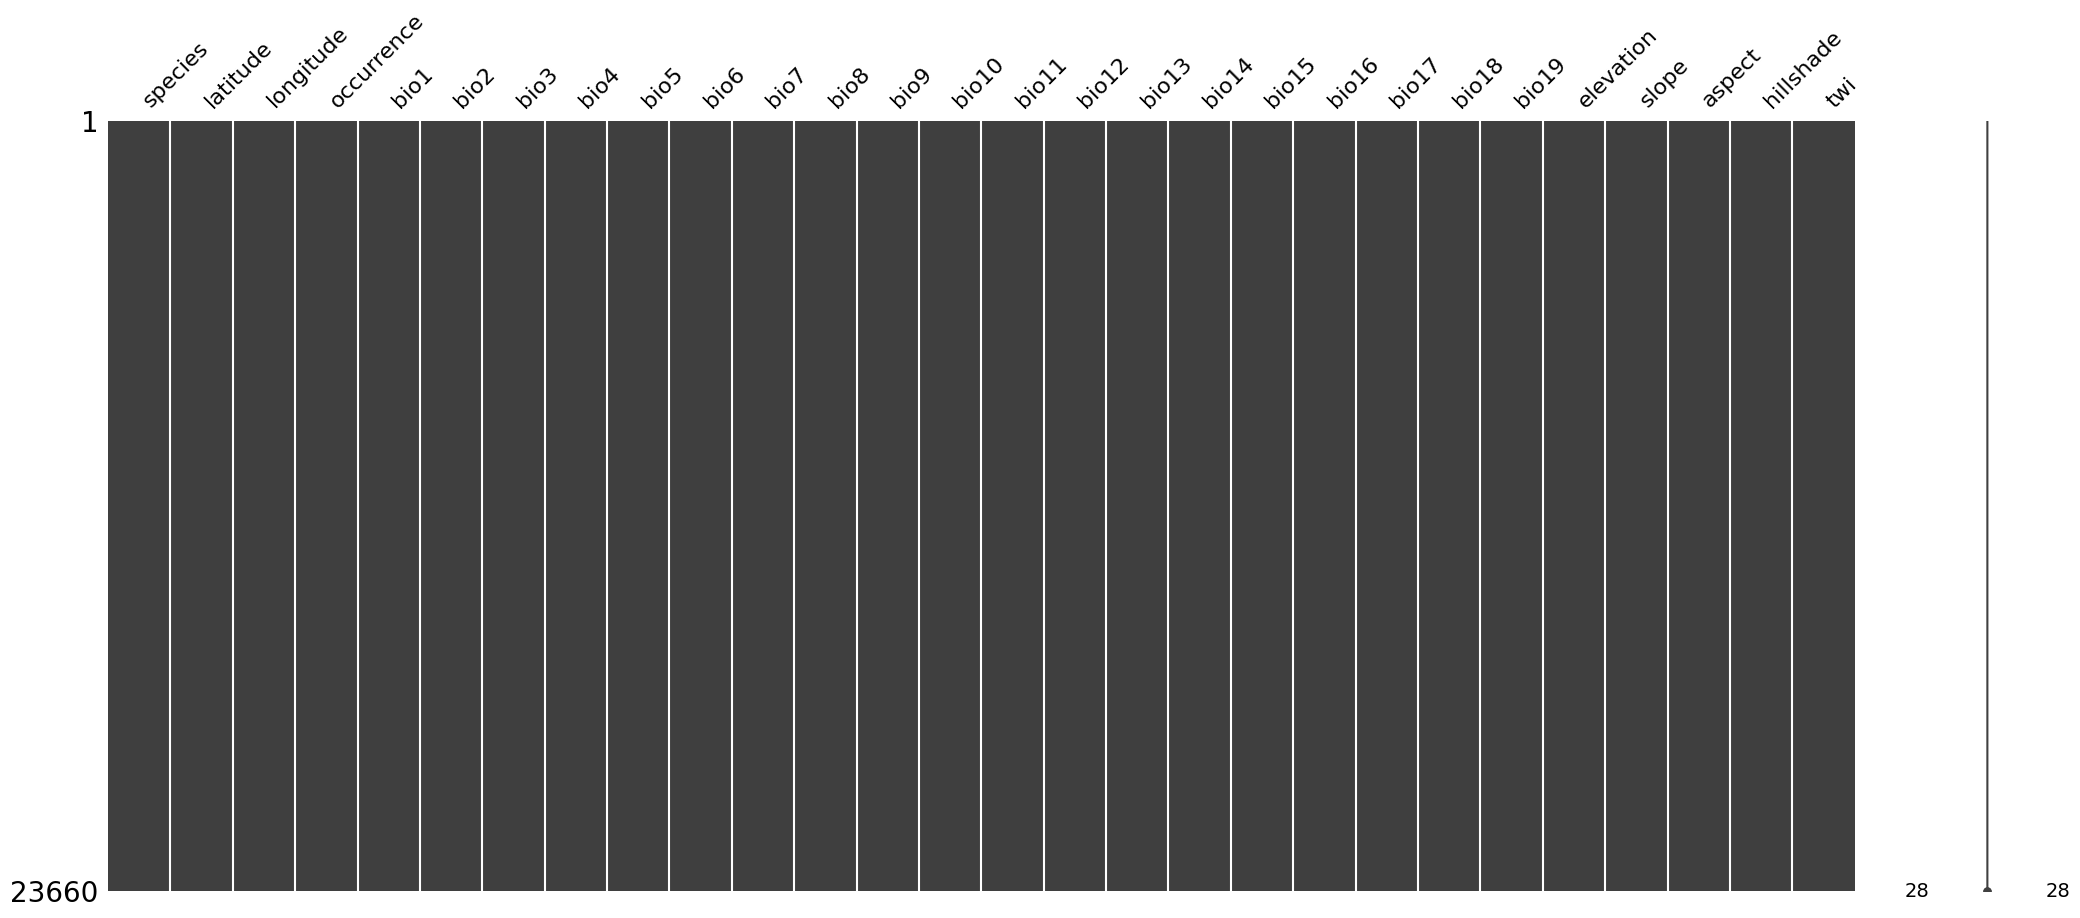

In [8]:
#Check for missing values
msno.matrix(df)

In [9]:
# Check for missing values in each column
missing_values_count = df.isnull().sum()

# Print the result
print("Number of missing values per column:")
print(missing_values_count)

Number of missing values per column:
species       0
latitude      0
longitude     0
occurrence    0
bio1          0
bio2          0
bio3          0
bio4          0
bio5          0
bio6          0
bio7          0
bio8          0
bio9          0
bio10         0
bio11         0
bio12         0
bio13         0
bio14         0
bio15         0
bio16         0
bio17         0
bio18         0
bio19         0
elevation     0
slope         0
aspect        0
hillshade     0
twi           0
dtype: int64


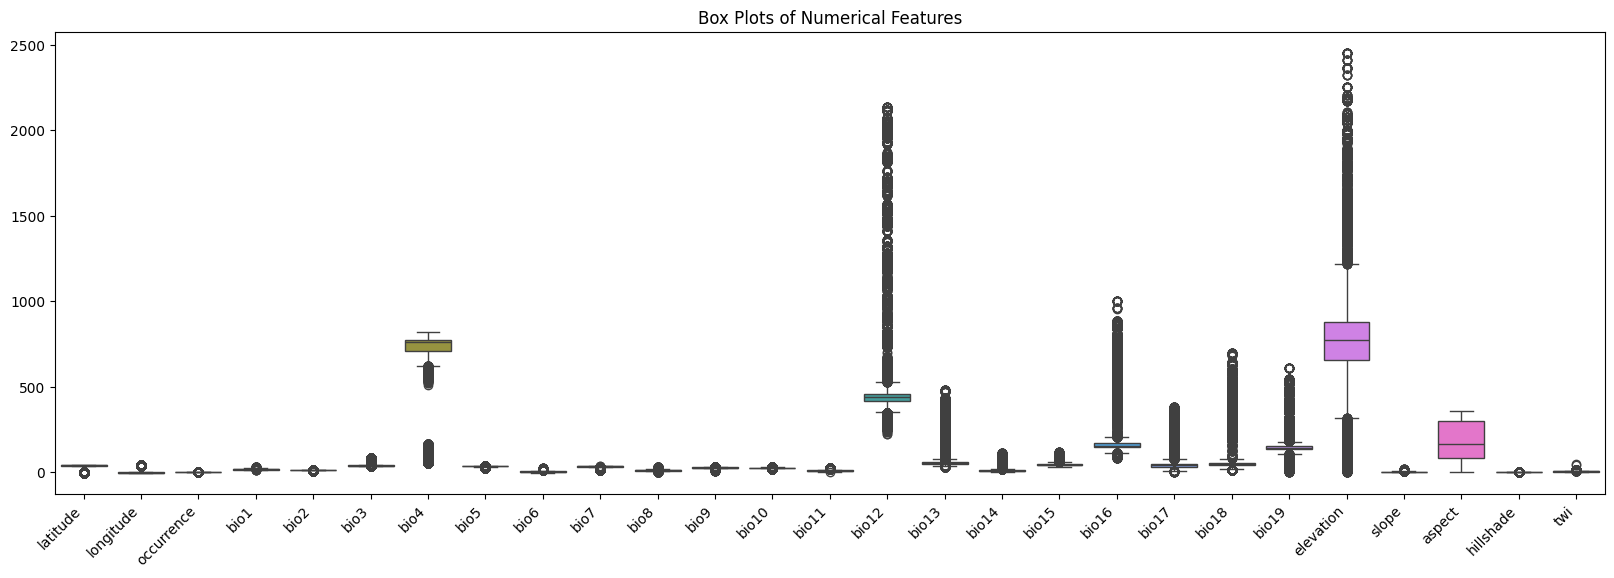

In [10]:
#Check if there are outliers
plt.figure(figsize=(20, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Box Plots of Numerical Features')
plt.show()

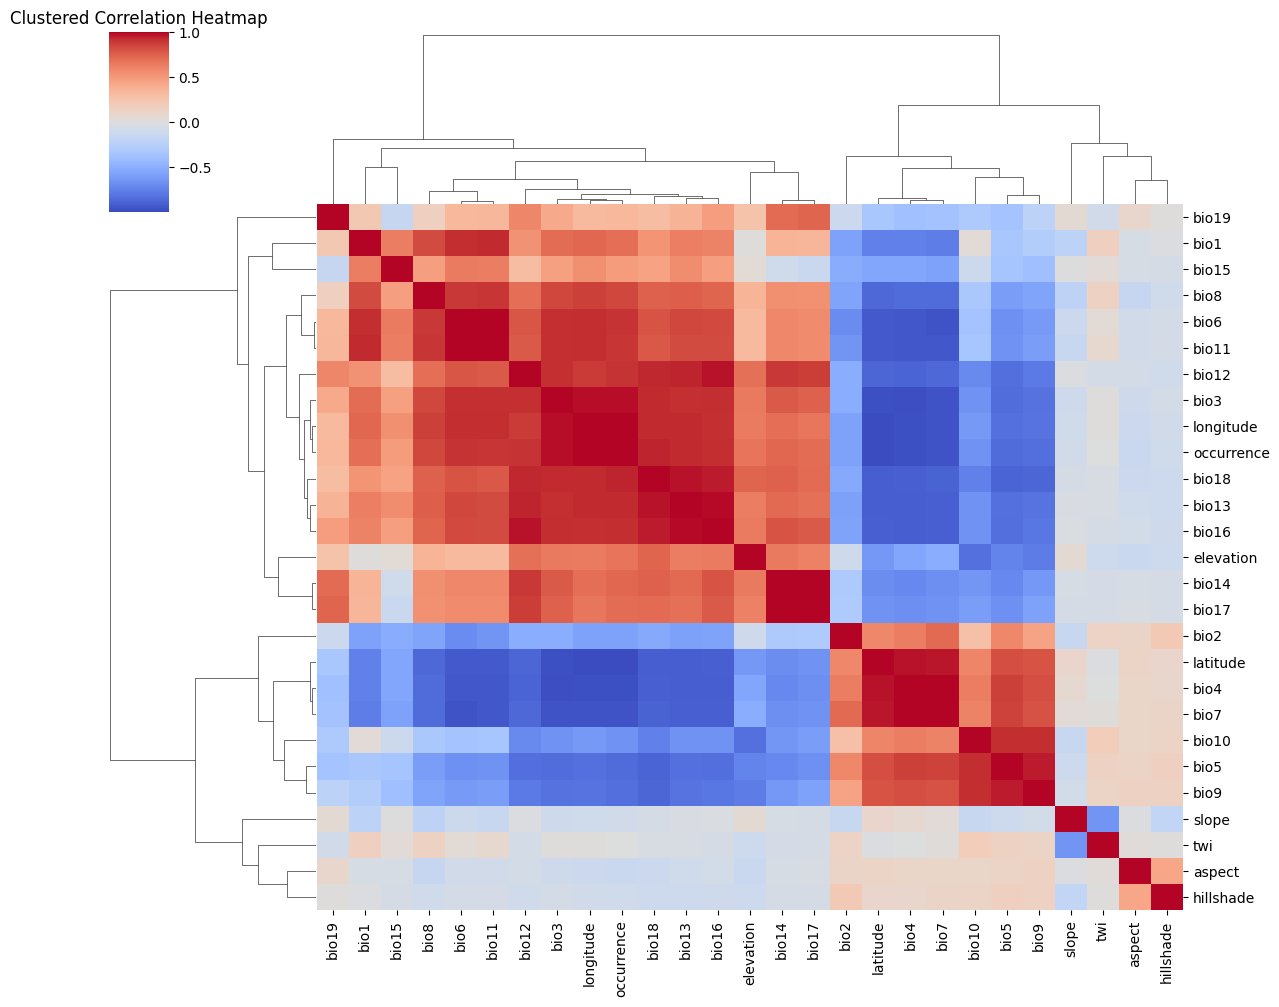

In [11]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns
df_numeric = df[numeric_cols]

# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

sns.clustermap(correlation_matrix, cmap='coolwarm', figsize=(12, 10), annot=False)
plt.title('Clustered Correlation Heatmap')
plt.show()

In [12]:
# 1. Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns
df_numeric = df[numeric_cols]

# 2. Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# 3. Unstack the correlation matrix to get a list of all pairs
# and sort them by absolute value
correlation_pairs = correlation_matrix.unstack().sort_values(kind="quicksort", ascending=False)

# 4. Filter for high correlations
# We'll filter for correlations that are above 0.7 (but not 1.0, which is self-correlation)
high_correlations = correlation_pairs[
    (correlation_pairs > 0.8) & (correlation_pairs < 1.0)
]
high_correlations.to_csv('high_correlations.csv')

In [16]:
# Get the unique species names
unique_species = df['species'].unique()

# Create a dictionary to store dataframes for each species
species_dfs = {}

# Iterate through unique species and create a dataframe for each
for species in unique_species:
    species_dfs[species] = df[df['species'] == species].copy()
    print(f"Created dataframe for {species} with shape: {species_dfs[species].shape}")

# You can now access each species dataframe like this:
acacia_df = species_dfs['Acacia']
eucalyptus_df = species_dfs['Eucalyptus']
grevillea_df = species_dfs['Grevillea']
musa_df = species_dfs['Musa']

Created dataframe for Acacia with shape: (4838, 28)
Created dataframe for Eucalyptus with shape: (5239, 28)
Created dataframe for Musa with shape: (4924, 28)
Created dataframe for Grevillea with shape: (8659, 28)


In [18]:
acacia_df.to_csv('acacia_df.csv')
eucalyptus_df.to_csv('eucalyptus_df.csv')
grevillea_df.to_csv('grevillea_df.csv')
musa_df.to_csv('musa_df.csv')

In [19]:
acacia_df.head()

,species,latitude,longitude,occurrence,bio1,bio2,bio3,bio4,bio5,bio6,...,bio15,bio16,bio17,bio18,bio19,elevation,slope,aspect,hillshade,twi
0,Acacia,-4.537429,39.139728,1,27.400000,9.0,64.699997,160.100006,34.500000,20.6,...,63.900002,539,142,174,192,74,0.614734,133.057430,0.699484,5.227901
15,Acacia,-4.000613,39.397586,1,26.299999,8.8,66.099998,149.800003,33.200001,19.9,...,51.599998,345,122,218,157,182,0.559727,33.576736,0.708441,5.321649
16,Acacia,-4.000612,39.397576,1,26.299999,8.8,66.099998,149.800003,33.200001,19.9,...,51.599998,345,122,218,157,182,0.559727,33.576736,0.708441,5.321649
17,Acacia,-4.000412,39.398595,1,26.299999,8.8,66.099998,149.800003,33.200001,19.9,...,51.599998,345,122,218,157,182,0.559727,33.576736,0.708441,5.321649
18,Acacia,-4.000398,39.398597,1,26.299999,8.8,66.099998,149.800003,33.200001,19.9,...,51.599998,345,122,218,157,182,0.559727,33.576736,0.708441,5.321649
